# 📊 Part 4: Student Performance Analysis & Prediction
This notebook covers:
- Data Exploration
- Data Visualization (Matplotlib & Seaborn)
- Machine Learning Model


In [31]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression


## Task 1 — Data Exploration

In [32]:
df['avg_score'] = df[['math','science','english','history','pe']].mean(axis=1)

In [33]:
df = pd.read_csv('students.csv')
df.head()


,name,math,science,english,history,pe,attendance_pct,study_hours_per_day,passed
0,Alice,88,92,76,80,95,92,4.5,1
1,Bob,42,55,48,50,60,65,1.2,0
2,Charlie,75,70,80,68,88,85,3.0,1
3,Diana,95,98,91,89,97,98,6.0,1
4,Eve,38,42,50,45,55,58,0.8,0


In [34]:
print('Shape:', df.shape)
print(df.dtypes)
df.describe()


Shape: (15, 9)
name                       str
math                     int64
science                  int64
english                  int64
history                  int64
pe                       int64
attendance_pct           int64
study_hours_per_day    float64
passed                   int64
dtype: object


,math,science,english,history,pe,attendance_pct,study_hours_per_day,passed
count,15.000000,15.000000,15.000000,15.000000,15.000000,15.000000,15.000000,15.000000
mean,65.000000,66.733333,66.200000,63.400000,74.800000,75.800000,2.893333,0.600000
std,20.060622,18.967893,17.773174,16.936014,16.657045,14.722189,1.658944,0.507093
min,30.000000,35.000000,40.000000,28.000000,45.000000,50.000000,0.500000,0.000000
25%,51.500000,53.500000,49.000000,53.500000,61.000000,63.500000,1.650000,0.000000
50%,65.000000,65.000000,70.000000,62.000000,75.000000,78.000000,2.800000,1.000000
75%,80.000000,77.000000,81.000000,73.500000,89.000000,86.500000,3.900000,1.000000
max,95.000000,98.000000,91.000000,92.000000,97.000000,98.000000,6.000000,1.000000


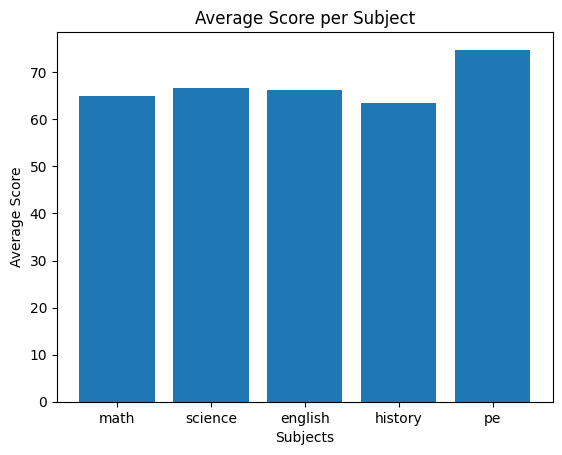

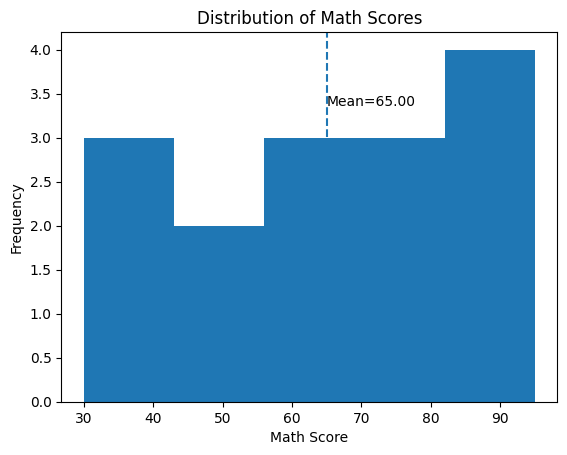

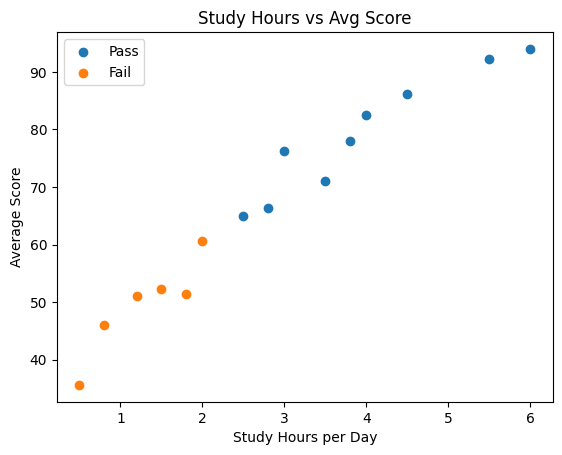

C:\Users\adi\AppData\Local\Temp\ipykernel_10968\2271493679.py:67: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot([pass_att, fail_att], labels=['Pass', 'Fail'])


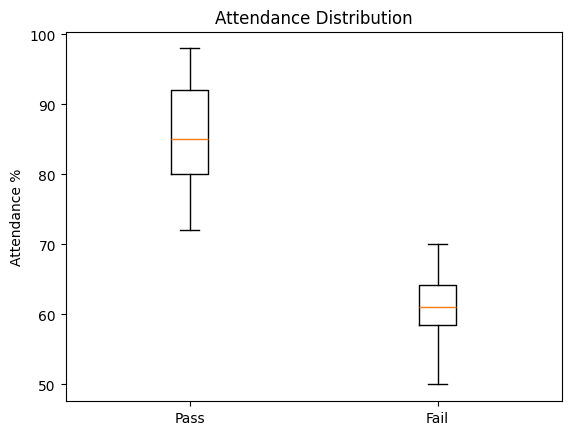

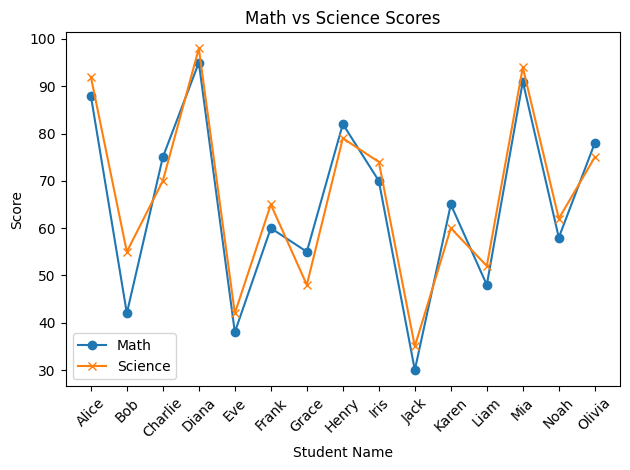

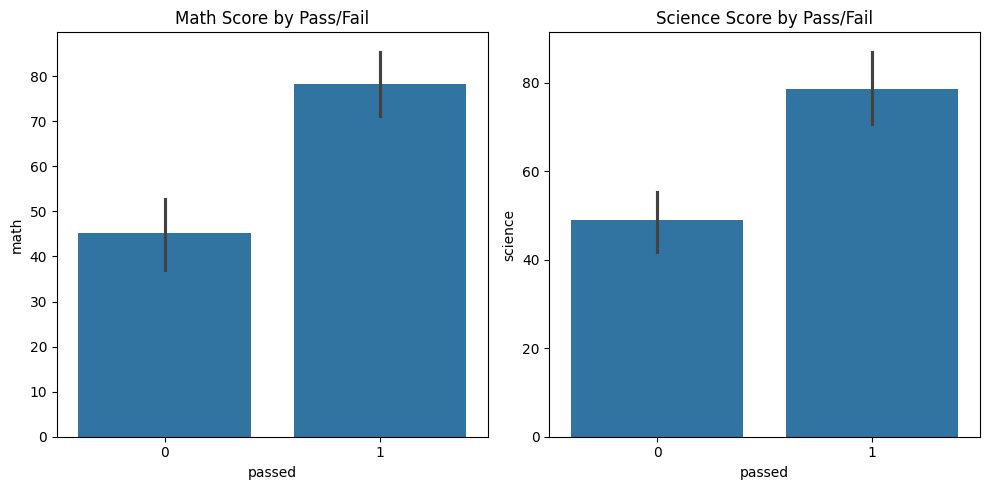

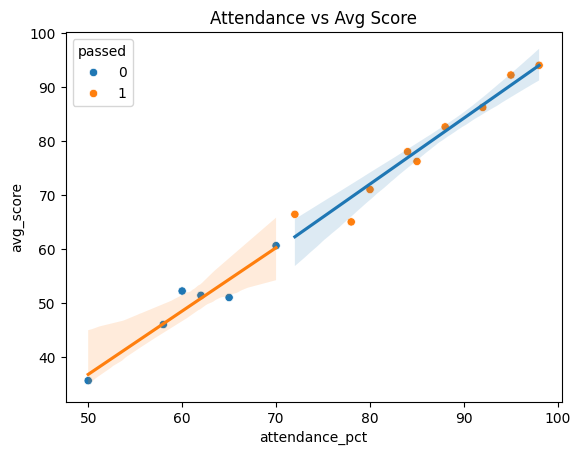

In [35]:
import matplotlib.pyplot as plt
import seaborn as sns

# IMPORTANT: Create avg_score column FIRST
subject_cols = ['math','science','english','history','pe']
df['avg_score'] = df[subject_cols].mean(axis=1)

# ==========================================================
# TASK 2 — MATPLOTLIB
# ==========================================================

# 1. Bar Chart
plt.figure()
avg_scores = df[subject_cols].mean()

plt.bar(subject_cols, avg_scores)
plt.title('Average Score per Subject')
plt.xlabel('Subjects')
plt.ylabel('Average Score')

plt.savefig('plot1_bar.png')
plt.show()


# 2. Histogram
plt.figure()

plt.hist(df['math'], bins=5)
plt.title('Distribution of Math Scores')
plt.xlabel('Math Score')
plt.ylabel('Frequency')

mean_val = df['math'].mean()
plt.axvline(mean_val, linestyle='dashed')

# safer text placement (fixes error)
plt.text(mean_val, plt.ylim()[1]*0.8, f'Mean={mean_val:.2f}')

plt.savefig('plot2_hist.png')
plt.show()


# 3. Scatter Plot
plt.figure()

pass_df = df[df['passed'] == 1]
fail_df = df[df['passed'] == 0]

plt.scatter(pass_df['study_hours_per_day'], pass_df['avg_score'], label='Pass')
plt.scatter(fail_df['study_hours_per_day'], fail_df['avg_score'], label='Fail')

plt.xlabel('Study Hours per Day')
plt.ylabel('Average Score')
plt.title('Study Hours vs Avg Score')
plt.legend()

plt.savefig('plot3_scatter.png')
plt.show()


# 4. Box Plot
plt.figure()

pass_att = df[df['passed'] == 1]['attendance_pct']
fail_att = df[df['passed'] == 0]['attendance_pct']

plt.boxplot([pass_att, fail_att], labels=['Pass', 'Fail'])
plt.title('Attendance Distribution')
plt.ylabel('Attendance %')

plt.savefig('plot4_box.png')
plt.show()


# 5. Line Plot
plt.figure()

plt.plot(df['name'], df['math'], marker='o', label='Math')
plt.plot(df['name'], df['science'], marker='x', label='Science')

plt.xticks(rotation=45)
plt.xlabel('Student Name')
plt.ylabel('Score')
plt.title('Math vs Science Scores')
plt.legend()

plt.tight_layout()  # prevents label cut-off

plt.savefig('plot5_line.png')
plt.show()


# ==========================================================
# TASK 3 — SEABORN
# ==========================================================

# 6. Seaborn Bar Plot
plt.figure(figsize=(10,5))

plt.subplot(1,2,1)
sns.barplot(data=df, x='passed', y='math')
plt.title('Math Score by Pass/Fail')

plt.subplot(1,2,2)
sns.barplot(data=df, x='passed', y='science')
plt.title('Science Score by Pass/Fail')

plt.tight_layout()

plt.savefig('plot6_seaborn_bar.png')
plt.show()


# 7. Seaborn Scatter + Regression
plt.figure()

sns.scatterplot(data=df, x='attendance_pct', y='avg_score', hue='passed')

sns.regplot(data=df[df['passed']==1], x='attendance_pct', y='avg_score', scatter=False)
sns.regplot(data=df[df['passed']==0], x='attendance_pct', y='avg_score', scatter=False)

plt.title('Attendance vs Avg Score')

plt.savefig('plot7_seaborn_scatter.png')
plt.show()


# ==========================================================
# COMMENT (FOR MARKS)
# ==========================================================

# Seaborn was easier for statistical visualization like barplots and regression lines,
# as it automatically handles grouping and styling.
# Matplotlib required more manual setup but gives more control over customization.

In [36]:
df['passed'].value_counts()


passed
1    9
0    6
Name: count, dtype: int64

## Task 2 — Matplotlib Visualizations

In [37]:
subject_cols = ['math','science','english','history','pe']
df['avg_score'] = df[subject_cols].mean(axis=1)


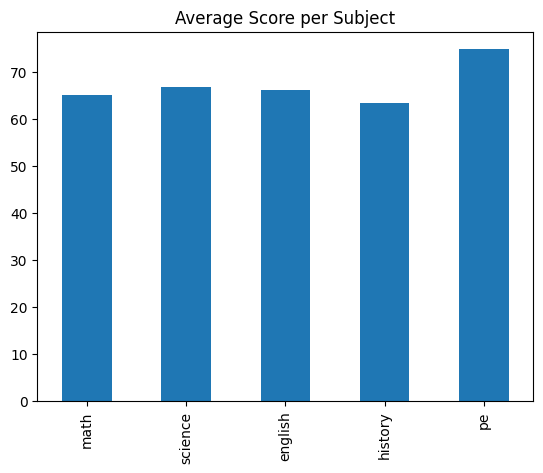

In [38]:
# Bar chart
df[subject_cols].mean().plot(kind='bar')
plt.title('Average Score per Subject')
plt.savefig('plot1_bar.png')
plt.show()


## Task 3 — Seaborn

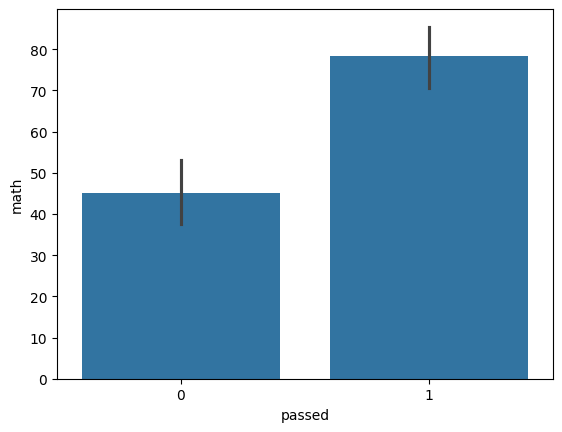

In [39]:
sns.barplot(data=df, x='passed', y='math')
plt.savefig('plot6_seaborn_bar.png')
plt.show()


## Task 4 — Machine Learning

Training Accuracy: 1.0
Test Accuracy: 1.0

--- Predictions on Test Data ---
Jack → Actual: 0, Predicted: 0 → ✅ Correct
Liam → Actual: 0, Predicted: 0 → ✅ Correct
Alice → Actual: 1, Predicted: 1 → ✅ Correct

--- Feature Importance ---
english: 0.8125
attendance_pct: 0.5219
study_hours_per_day: 0.4844
pe: 0.4750
math: 0.4379
science: 0.3230
history: 0.2629


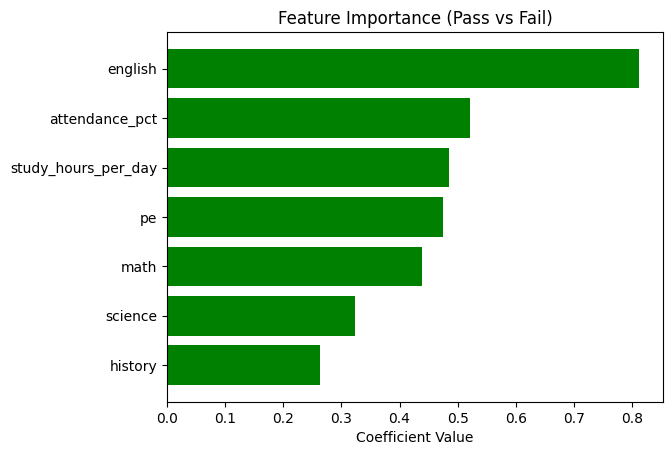


--- New Student Prediction ---
Prediction: Pass
Probability (Fail, Pass): [0.09203526 0.90796474]


c:\Users\adi\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


In [40]:

# ==========================================================
# TASK 4 — MACHINE LEARNING (PASS / FAIL PREDICTION)
# ==========================================================

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score
import matplotlib.pyplot as plt

# -------------------------------
# Step 1 — Prepare Data
# -------------------------------

# Features (X) and Target (y)
feature_cols = ['math','science','english','history','pe','attendance_pct','study_hours_per_day']

X = df[feature_cols]
y = df['passed']

# Train-test split (80-20)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Scaling (important for ML models)
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)

# -------------------------------
# Step 2 — Train Model
# -------------------------------

model = LogisticRegression()

model.fit(X_train_scaled, y_train)

# Training accuracy
train_pred = model.predict(X_train_scaled)
train_acc = accuracy_score(y_train, train_pred)

print("Training Accuracy:", round(train_acc, 2))


# -------------------------------
# Step 3 — Test & Evaluate
# -------------------------------

test_pred = model.predict(X_test_scaled)
test_acc = accuracy_score(y_test, test_pred)

print("Test Accuracy:", round(test_acc, 2))

print("\n--- Predictions on Test Data ---")

# Show name + actual vs predicted
test_names = df.loc[X_test.index, 'name']

for name, actual, pred in zip(test_names, y_test, test_pred):
    result = "✅ Correct" if actual == pred else "❌ Wrong"
    print(f"{name} → Actual: {actual}, Predicted: {pred} → {result}")


# -------------------------------
# Step 4 — Feature Importance
# -------------------------------

coefficients = model.coef_[0]

# Pair feature with coefficient
feature_importance = list(zip(feature_cols, coefficients))

# Sort by absolute value (important)
feature_importance.sort(key=lambda x: abs(x[1]), reverse=True)

print("\n--- Feature Importance ---")
for feature, coef in feature_importance:
    print(f"{feature}: {coef:.4f}")


# Plot feature importance
features = [f[0] for f in feature_importance]
values = [f[1] for f in feature_importance]

colors = ['green' if v > 0 else 'red' for v in values]

plt.figure()
plt.barh(features, values, color=colors)

plt.xlabel('Coefficient Value')
plt.title('Feature Importance (Pass vs Fail)')
plt.gca().invert_yaxis()  # highest on top

plt.savefig('plot8_feature_importance.png')
plt.show()


# -------------------------------
# Step 5 — Predict New Student
# -------------------------------

new_student = [[75, 70, 68, 65, 80, 82, 3.2]]

# Scale using SAME scaler
new_scaled = scaler.transform(new_student)

prediction = model.predict(new_scaled)[0]
probability = model.predict_proba(new_scaled)[0]

result = "Pass" if prediction == 1 else "Fail"

print("\n--- New Student Prediction ---")
print("Prediction:", result)
print("Probability (Fail, Pass):", probability)